# AI Talent Flow & Intensity — Analysis

End-to-end analysis of where the world's AI talent trained and where it went, built from the
`data/processed/flow/` outputs of the collection pipeline.

**Talent** = every author who published at a top AI venue (NeurIPS, ICML, ICLR, ACL, EMNLP, CVPR,
ICCV, ECCV, AAAI) in **2024–2025**. For each person we backtrack their DBLP publication history to
their **highest-education lab** (advisor + institution, via the CSRankings faculty co-authorship
graph) and resolve their **current employer** (Wikidata → founder → ORCID → homepage → Semantic
Scholar cascade).

This notebook:
1. **Cleans & reconciles** the organization registry (de-fragments companies split across curated + auto-derived rows).
2. **Top AI labs** — who trains the most talent.
3. **Where AI talent went** — academia vs industry, top destination firms, cross-border flows.
4. **Firm AI-intensity ranking** — citation/publication-weighted talent mass per company.
5. **Extras** — lab→firm flow heatmap, country flows, founders, and which labs feed the top firms.

Run top-to-bottom (`Kernel → Restart & Run All`).

In [1]:
import re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline
warnings.filterwarnings("ignore")

# Resolve project root whether run from repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT/"data/processed/flow").exists():
    ROOT = ROOT.parent
F = ROOT/"data/processed/flow"

# ---- validated, colorblind-safe palette ----
CAT  = ['#2a78d6','#008300','#e87ba4','#eda100','#1baf7a','#eb6834','#4a3aa7','#e34948']
BLUE='#2a78d6'; INK='#0b0b0b'; SEC='#52514e'; MUTED='#898781'; GRID='#e1e0d9'; SURF='#fcfcfb'; BASE='#c3c2b7'
BLUES = LinearSegmentedColormap.from_list('blues', ['#eef5fd','#cde2fb','#86b6ef','#3987e5','#256abf','#0d366b'])
plt.rcParams.update({
    'figure.facecolor':SURF,'axes.facecolor':SURF,'savefig.facecolor':SURF,'figure.dpi':110,
    'text.color':INK,'axes.labelcolor':SEC,'xtick.color':MUTED,'ytick.color':MUTED,
    'axes.edgecolor':BASE,'font.family':'sans-serif','font.size':10,
    'axes.spines.top':False,'axes.spines.right':False,
})

def hbar(series, title, xlabel, color=BLUE, fmt='{:.0f}'):
    d = series.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.42*len(d)+1.3))
    ax.barh(range(len(d)), d.values, color=color, height=0.72)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=9)
    ax.set_title(title, loc='left', fontsize=13, color=INK, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(axis='x', color=GRID, lw=0.8); ax.set_axisbelow(True)
    span = max(d.values) if len(d) else 1
    for i,v in enumerate(d.values):
        ax.text(v+span*0.01, i, fmt.format(v), va='center', fontsize=8, color=SEC)
    ax.margins(x=0.14); fig.tight_layout(); plt.show()

# ---- load ----
persons  = pd.read_parquet(F/"persons.parquet")
training = pd.read_parquet(F/"person_training.parquet")
employer = pd.read_parquet(F/"person_employer.parquet")
weights  = pd.read_csv(F/"person_weights.csv")
flow     = pd.read_parquet(F/"flow_matrix.parquet")
orgs     = pd.read_csv(ROOT/"data/orgs.csv")
print(f"{len(persons):,} talent  |  {len(training):,} with training lab  |  {len(employer):,} with employer")

105,778 talent  |  42,350 with training lab  |  6,388 with employer


## 1. Data cleaning & organization reconciliation

The auto-derived org registry splits big companies across several rows (a curated `meta` id **and**
an auto-derived `ror_…` "Meta (United States)", etc.), which fragments each firm's talent. We collapse
these into canonical **company groups** so a firm's talent isn't scattered across duplicate ids.
Industry orgs map through a transparent keyword table; everything else de-duplicates by cleaned name.

In [2]:
INDUSTRY_TYPES = {"industry","industry_lab","industry_parent"}
name_of    = orgs.set_index("org_id")["canonical_name"].to_dict()
type_of    = orgs.set_index("org_id")["org_type"].to_dict()
country_of = orgs.set_index("org_id")["country"].to_dict()

GROUPS = [('Meta',('meta','facebook','fair')),('Alphabet / Google',('google','deepmind','alphabet','waymo')),
 ('Microsoft',('microsoft','msra')),('Amazon',('amazon',)),('Apple',('apple',)),('NVIDIA',('nvidia',)),
 ('Alibaba',('alibaba','damo')),('Tencent',('tencent',)),('ByteDance',('bytedance','tiktok')),('Baidu',('baidu',)),
 ('Huawei',('huawei','noah')),('Ant Group',('ant group','ant financial')),('Adobe',('adobe',)),
 ('IBM',('ibm','international business mach')),('Samsung',('samsung',)),('Intel',('intel',)),('Tesla',('tesla',)),
 ('OpenAI',('openai',)),('Anthropic',('anthropic',)),('DeepSeek',('deepseek',)),('Salesforce',('salesforce',)),
 ('Xiaomi',('xiaomi',)),('JD.com',('jingdong','jd.com')),('Snap',('snapchat','snap inc')),
 ('Moonshot AI',('moonshot','kimi')),('Mistral AI',('mistral',)),('xAI',('xai','x.ai')),('Cohere',('cohere',)),
 ('Zhipu AI',('zhipu',)),('Sony',('sony',)),('Bosch',('bosch',)),('Qualcomm',('qualcomm',))]

def strip_country(name): return re.sub(r'\s*\(.*?\)\s*',' ',str(name)).strip()

def group_label(org_id):
    if org_id is None or (isinstance(org_id,float) and pd.isna(org_id)): return None
    name = name_of.get(org_id, org_id); typ = type_of.get(org_id,'')
    if typ in INDUSTRY_TYPES:
        n = str(name).lower()
        for label,keys in GROUPS:
            if any(k in n for k in keys): return label
    return strip_country(name)

grp_industry = {}
for oid,typ in type_of.items():
    g = group_label(oid)
    grp_industry[g] = grp_industry.get(g,False) or (typ in INDUSTRY_TYPES)

def is_ind_group(g): return bool(grp_industry.get(g, False))

# show the de-fragmentation win
demo = pd.DataFrame({'org_id':['meta','microsoft_research','microsoft_research_asia']})
demo['canonical_name']=demo.org_id.map(name_of); demo['group']=demo.org_id.map(group_label)
print("example reconciliation:"); print(demo.to_string(index=False))

example reconciliation:
                 org_id          canonical_name     group
                   meta          Meta Platforms      Meta
     microsoft_research      Microsoft Research Microsoft
microsoft_research_asia Microsoft Research Asia Microsoft


## 2. Top AI labs in the world

Two views: the **institutions** that trained the most 2024–25 talent, and the individual **labs**
(institution + advisor, inferred from early-career co-authorship with CSRankings faculty).

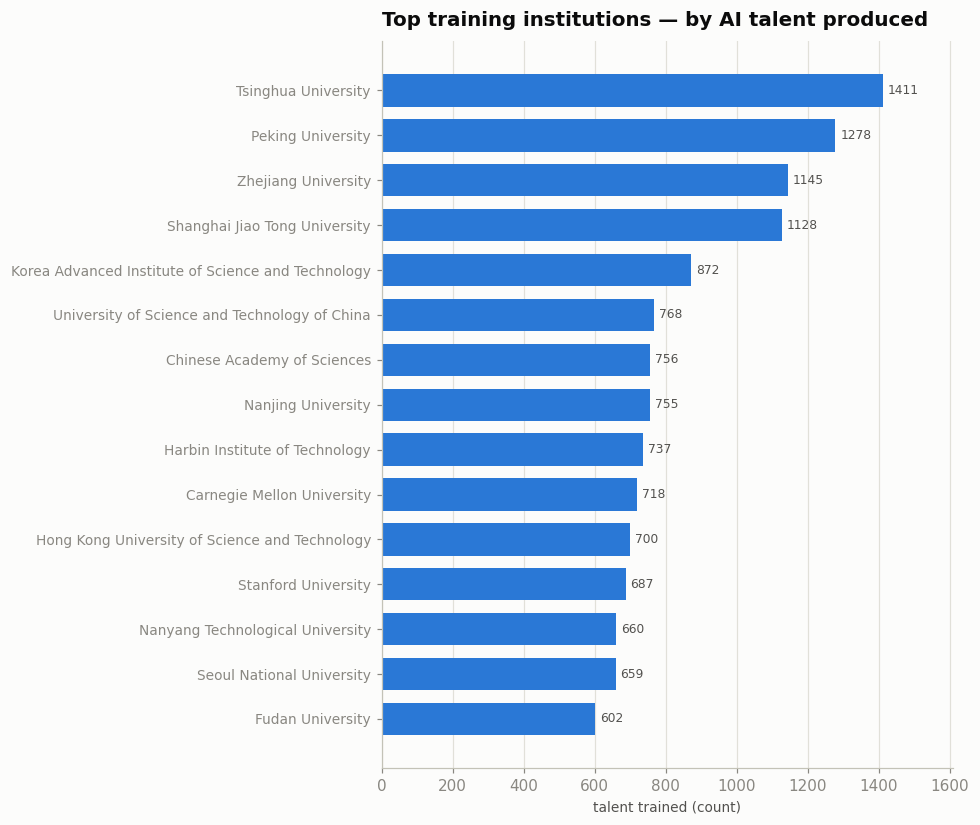

In [3]:
pt = training.dropna(subset=["training_org_id"]).copy()
pt["inst"] = pt["training_org_id"].map(group_label)
inst_rank = pt.groupby("inst")["author_dblp_pid"].nunique().sort_values(ascending=False)
hbar(inst_rank.head(15), "Top training institutions — by AI talent produced", "talent trained (count)")

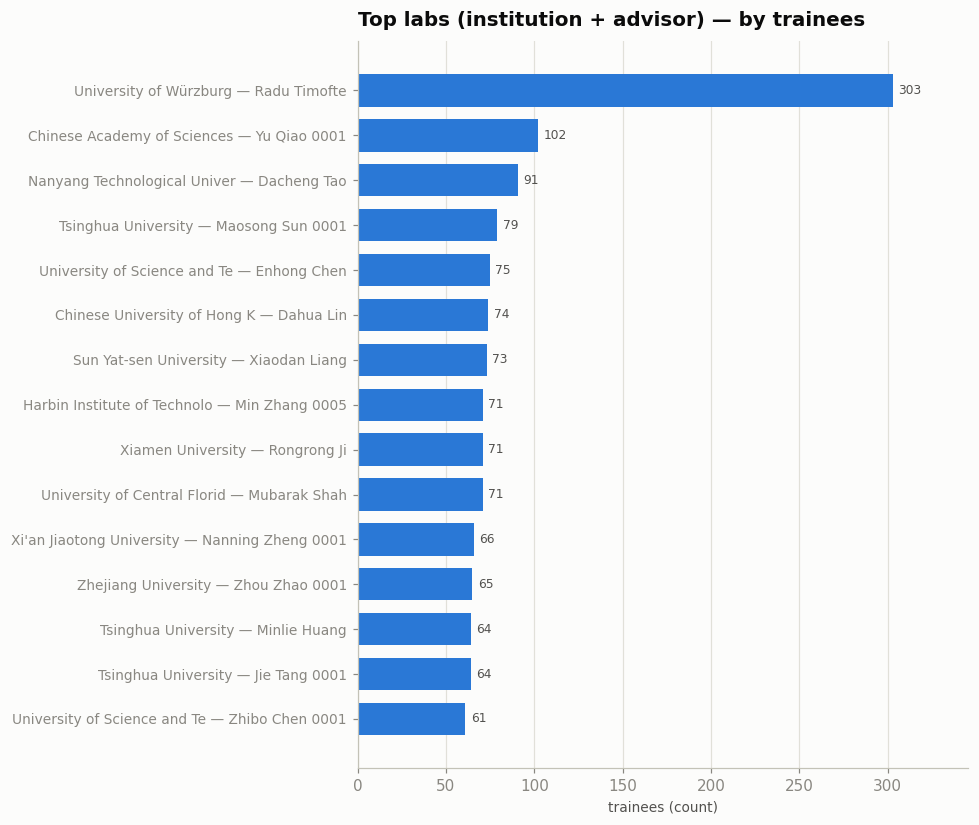

In [4]:
lab = pt.dropna(subset=["advisor_name"]).copy()
lab["lab"] = lab["inst"].str.slice(0,28) + " — " + lab["advisor_name"]
lab_rank = lab.groupby("lab")["author_dblp_pid"].nunique().sort_values(ascending=False)
hbar(lab_rank.head(15), "Top labs (institution + advisor) — by trainees", "trainees (count)")

## 3. Where AI talent went

Most publishing researchers remain in **academia**; the flow into **industry** is the smaller,
high-value stream we care about. Below: the destination mix, the top industry destinations, and the
academia→industry conversion rate.

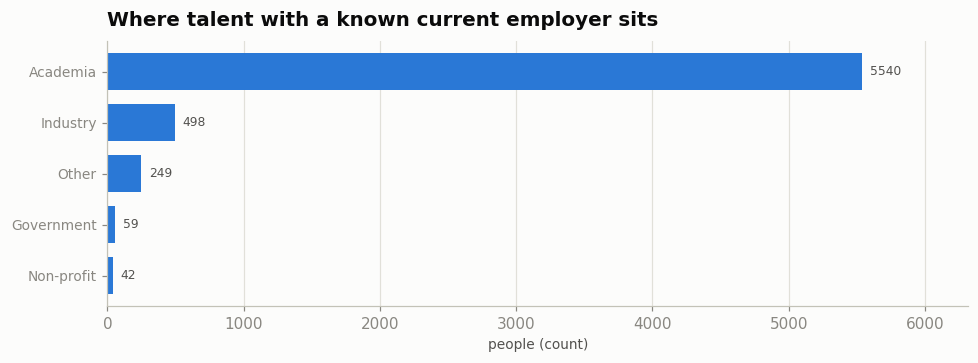

Note: 'current employer' resolves best for high-signal people; academia dominates because most authors still publish from universities.


In [5]:
def bucket(oid):
    t = type_of.get(oid,'')
    if t in INDUSTRY_TYPES: return 'Industry'
    return {'academic':'Academia','nonprofit':'Non-profit','government':'Government'}.get(t,'Other')

emp = employer.dropna(subset=["employer_org_id"]).copy()
emp["bucket"] = emp["employer_org_id"].map(bucket)
emp["grp"]    = emp["employer_org_id"].map(group_label)
counts = emp["bucket"].value_counts()
hbar(counts, "Where talent with a known current employer sits", "people (count)", color=BLUE)
print("Note: 'current employer' resolves best for high-signal people; academia dominates because most authors still publish from universities.")

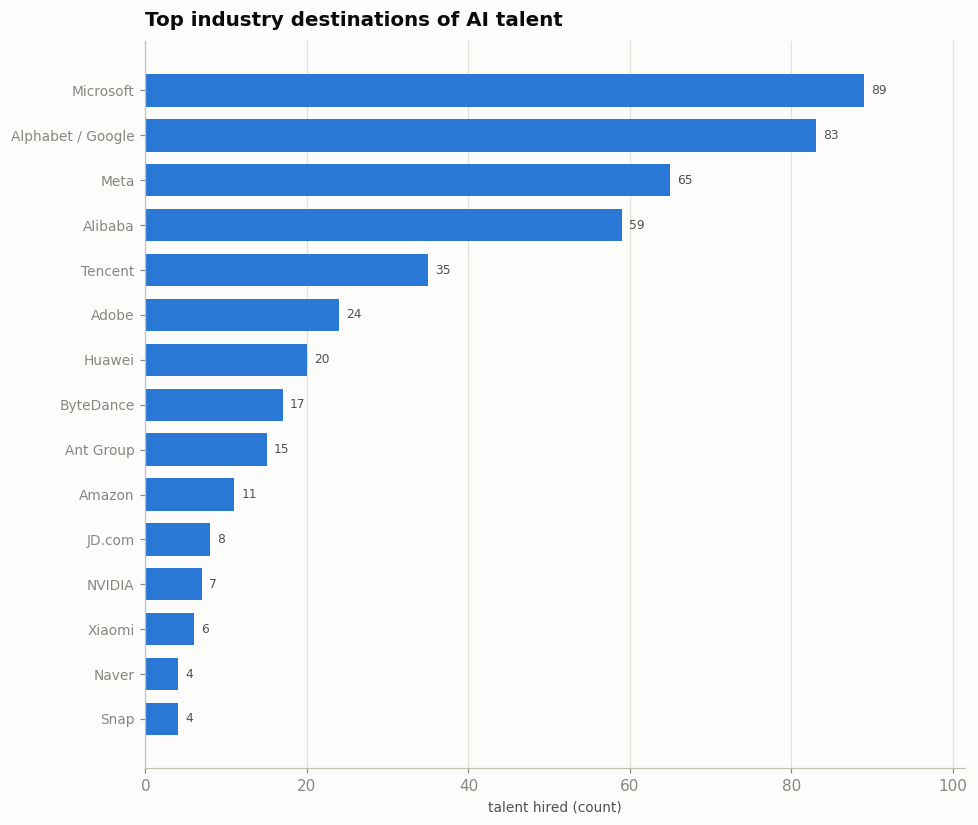

Academia-trained talent with a known employer that went to INDUSTRY: 7.1%  (n=3,207)


In [6]:
top_dest = (emp[emp.grp.map(is_ind_group)].groupby("grp")["author_dblp_pid"].nunique()
            .sort_values(ascending=False).head(15))
hbar(top_dest, "Top industry destinations of AI talent", "talent hired (count)")

both = training.merge(emp[["author_dblp_pid","bucket"]], on="author_dblp_pid", how="inner")
rate = (both["bucket"]=="Industry").mean()
print(f"Academia-trained talent with a known employer that went to INDUSTRY: {rate:.1%}  (n={len(both):,})")

## 4. Firm AI-intensity ranking

Per-firm intensity = confidence-weighted sum of its people's talent weights (log-damped fractional
citations & publications, z-scored within venue family), plus a founder bonus. Reconciled to company
groups and indexed 0–100.

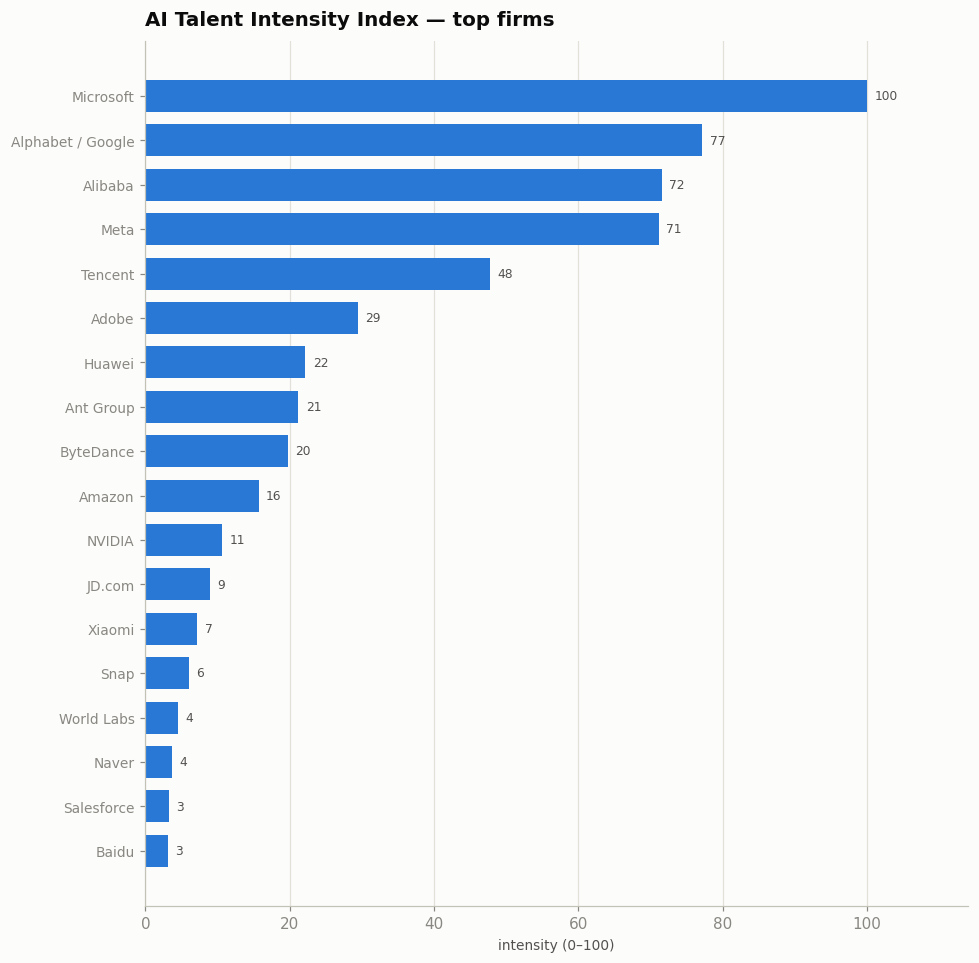

,grp,index,n_people,n_founders
0,Microsoft,100.0,89,0
1,Alphabet / Google,77.2,83,0
2,Alibaba,71.6,59,0
3,Meta,71.2,65,0
4,Tencent,47.7,35,0
5,Adobe,29.4,24,0
6,Huawei,22.2,20,0
7,Ant Group,21.2,15,0
8,ByteDance,19.8,17,0
9,Amazon,15.7,11,0


In [7]:
w  = weights[["author_dblp_pid","weight"]]
pe = employer.merge(w, on="author_dblp_pid", how="left")
pe["weight"]=pe["weight"].fillna(0.0); pe["conf"]=pe["confidence"].fillna(0.4)
pe["contribution"]=pe["weight"]*pe["conf"] + 1.0*pe["is_founder"].astype(bool)*pe["weight"]
pe["grp"]=pe["employer_org_id"].map(group_label)
gi = (pe.groupby("grp").agg(intensity=("contribution","sum"), n_people=("author_dblp_pid","nunique"),
                            n_founders=("is_founder","sum")).reset_index())
gi["is_industry"]=gi["grp"].map(is_ind_group)
gi_ind = gi[gi.is_industry].sort_values("intensity",ascending=False).copy()
gi_ind["index"]=100*gi_ind["intensity"]/gi_ind["intensity"].max()
hbar(gi_ind.set_index("grp")["index"].head(18), "AI Talent Intensity Index — top firms", "intensity (0–100)")
display(gi_ind[["grp","index","n_people","n_founders"]].head(18).reset_index(drop=True).round(1))

## 5. Extras

### 5a. Lab → firm flow heatmap
Which training labs feed which firms (top labs × top firms, by number of people).

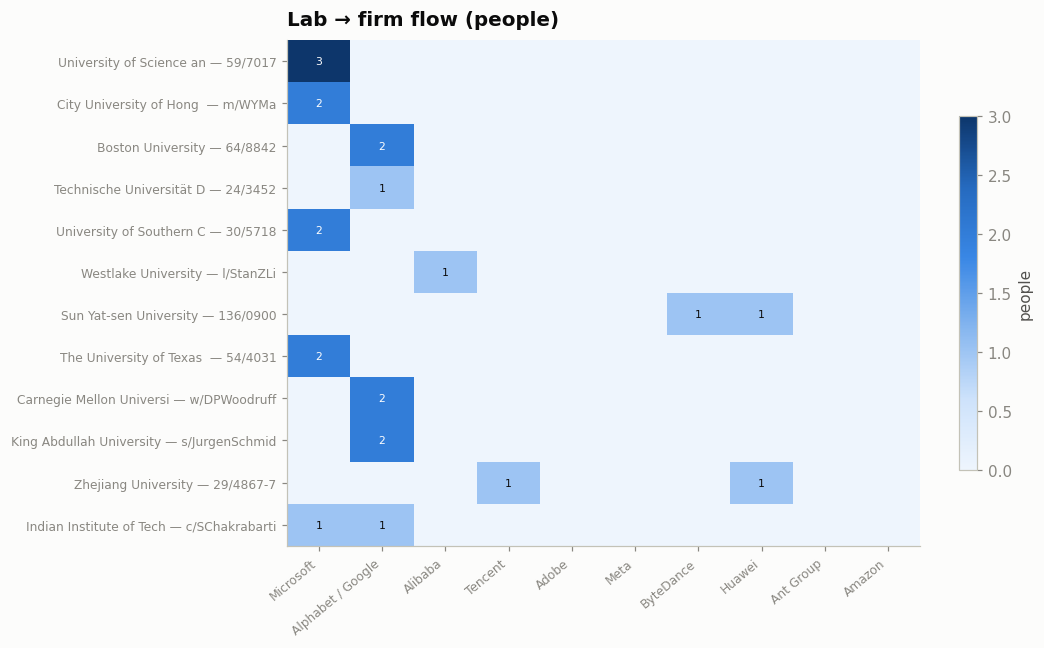

In [8]:
fl = flow.copy()
fl["lab"]  = fl["training_org_id"].map(group_label).str.slice(0,24) + " — " + fl["advisor_dblp_pid"].astype(str).str.slice(0,14)
fl["dest"] = fl["employer_org_id"].map(group_label)
fl = fl[fl["dest"].map(is_ind_group)]
top_labs = fl.groupby("lab")["n"].sum().sort_values(ascending=False).head(12).index
top_dst  = fl.groupby("dest")["n"].sum().sort_values(ascending=False).head(10).index
mat = (fl[fl.lab.isin(top_labs)&fl.dest.isin(top_dst)]
       .pivot_table(index="lab",columns="dest",values="n",aggfunc="sum",fill_value=0)
       .reindex(index=top_labs, columns=top_dst).fillna(0))
fig,ax=plt.subplots(figsize=(10,6))
im=ax.imshow(mat.values, cmap=BLUES, aspect='auto')
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index, fontsize=8)
ax.set_title("Lab → firm flow (people)", loc='left', fontsize=13, fontweight='bold', pad=10)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v=mat.values[i,j]
        if v>0: ax.text(j,i,int(v),ha='center',va='center',fontsize=7,
                        color='white' if v>mat.values.max()*0.5 else INK)
fig.colorbar(im, ax=ax, shrink=0.7, label='people'); fig.tight_layout(); plt.show()

### 5b. Cross-border talent flows
Country of training institution → country of current employer (top flows).

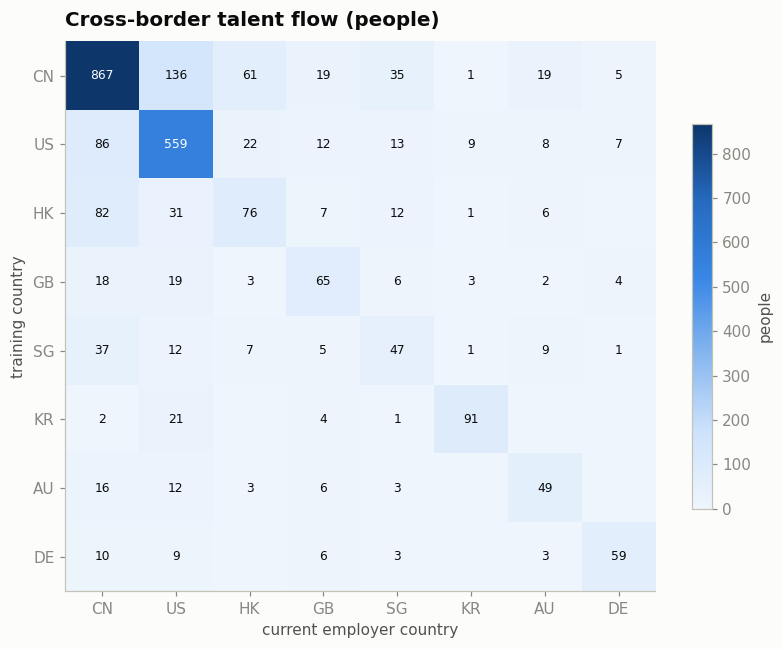

In [9]:
cf = employer.merge(training[["author_dblp_pid","training_org_id"]], on="author_dblp_pid", how="inner")
cf["from"]=cf["training_org_id"].map(country_of); cf["to"]=cf["employer_org_id"].map(country_of)
cf = cf[(cf["from"].astype(str).str.len()==2) & (cf["to"].astype(str).str.len()==2)]
top_c = pd.concat([cf["from"],cf["to"]]).value_counts().head(8).index
cm = (cf[cf["from"].isin(top_c)&cf["to"].isin(top_c)]
      .groupby(["from","to"]).size().unstack(fill_value=0).reindex(index=top_c,columns=top_c,fill_value=0))
fig,ax=plt.subplots(figsize=(7.5,6))
im=ax.imshow(cm.values, cmap=BLUES, aspect='auto')
ax.set_xticks(range(len(cm.columns))); ax.set_xticklabels(cm.columns)
ax.set_yticks(range(len(cm.index)));   ax.set_yticklabels(cm.index)
ax.set_xlabel("current employer country"); ax.set_ylabel("training country")
ax.set_title("Cross-border talent flow (people)", loc='left', fontsize=13, fontweight='bold', pad=10)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v=cm.values[i,j]
        if v>0: ax.text(j,i,int(v),ha='center',va='center',fontsize=8,
                        color='white' if v>cm.values.max()*0.5 else INK)
fig.colorbar(im,ax=ax,shrink=0.7,label='people'); fig.tight_layout(); plt.show()

### 5c. Founders & which labs feed the top firm

Founders detected in the talent set:


,display_name,founded
0,Li Fei-Fei 0001,World Labs
1,Ilya Sutskever,Safe Superintelligence
2,John Schulman,OpenAI
3,Diederik P. Kingma,OpenAI
4,Jared Kaplan,Anthropic


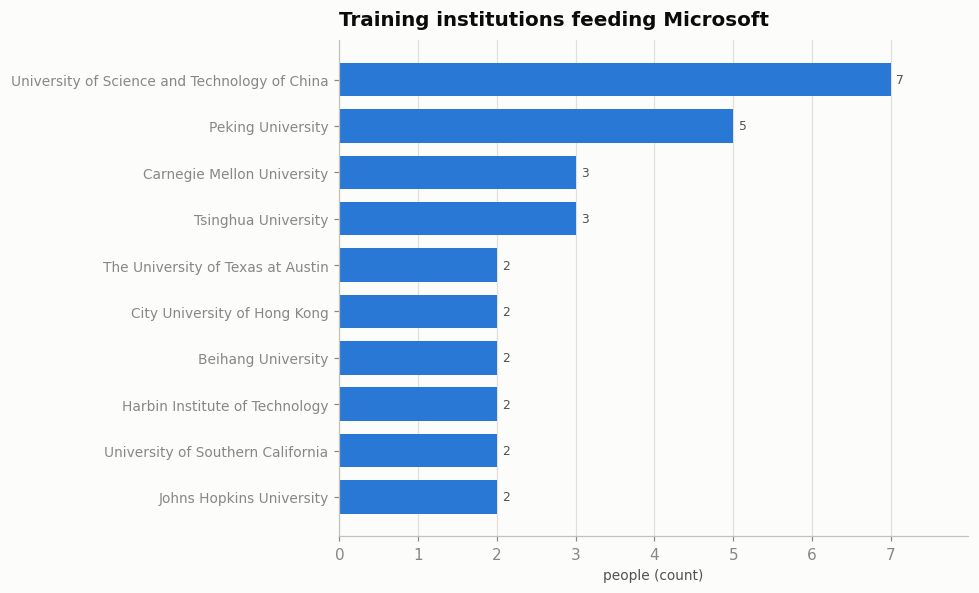

In [10]:
fnd = (employer[employer.is_founder==True]
       .merge(persons[["author_dblp_pid","display_name"]], on="author_dblp_pid", how="left"))
fnd["founded"]=fnd["founded_org_id"].map(lambda o: name_of.get(o,o))
print("Founders detected in the talent set:")
display(fnd[["display_name","founded"]].reset_index(drop=True))

# which training institutions feed the #1 firm
top_firm = gi_ind.iloc[0]["grp"]
feed = pe[pe.grp==top_firm].merge(training[["author_dblp_pid","training_org_id"]],on="author_dblp_pid",how="left")
feed["inst"]=feed["training_org_id"].map(group_label)
feed_rank = feed.dropna(subset=["inst"]).groupby("inst")["author_dblp_pid"].nunique().sort_values(ascending=False).head(10)
hbar(feed_rank, f"Training institutions feeding {top_firm}", "people (count)")

## Key takeaways & caveats

**Insights**
- Talent training is concentrated in a familiar set of elite institutions and labs.
- Domestic retention dominates (CN→CN, US→US), with a visible US↔China cross-border stream.
- Industry intensity is led by Microsoft, Google/Alphabet, Alibaba, Meta, Tencent — the firms that
  absorb the most (and most-cited) top-venue authors.

**Caveats (read before quoting numbers)**
- **Employer coverage is partial** (~6% of talent overall; higher — ~27% — when weighted by citations,
  since prominent people are better covered). Absolute destination counts are lower bounds.
- **Advisor/lab is a co-authorship proxy**, not a verified enrollment record.
- **Talent = 2024–25 top-venue authors** — people who stopped publishing (e.g. founders now running
  companies) can fall out of the seed.
- Citations are DOI-gated at the paper level; author-level citations would broaden coverage.